# DSP Signal Visualization

Loads the newest `debug_<TIMESTAMP>.csv` from the `data/` dir and plots the raw and filtered acceleration magnitudes from the digital signal processing thread when running `tools/debug_stream.py`. 

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = REPO_ROOT / "data"
OPTIONAL_DATA_FILEPATH = None

## 1. Load data

In [2]:
candidates = sorted(DATA_DIR.glob("debug_*.csv"), key=lambda p: p.stat().st_mtime)
if not candidates:
    raise FileNotFoundError(f"no debug_*.csv under {DATA_DIR}")

csv_path = OPTIONAL_DATA_FILEPATH if OPTIONAL_DATA_FILEPATH else candidates[-1]
print(f"Using: {csv_path.name}")

df = pd.read_csv(csv_path)
df = df.sort_values(by="timestampUs")

# Remove the 0 timestamp row
df = df.iloc[1:]

# Time axis: seconds from first sample (microsecond timestamps from firmware)
t = (df["timestampUs"] - df["timestampUs"].iloc[0]) * 1e-6

df.head()

Using: debug_20260430_140952.csv


,timestampUs,ax,ay,az,mag,slope
0,1402099277,0.431740,-0.002651,-0.058091,0.280933,0.048602
1,1402109165,0.080457,-0.000085,-0.008862,0.233124,-0.047809
2,1402119053,-0.011586,-0.000082,0.003835,0.180311,-0.052812
3,1402128942,-0.034904,0.001104,0.006322,0.145691,-0.034621
4,1402138830,-0.041178,0.001070,0.008378,0.120911,-0.024779


## 2. Time series: accelerations (ax, ay, az)

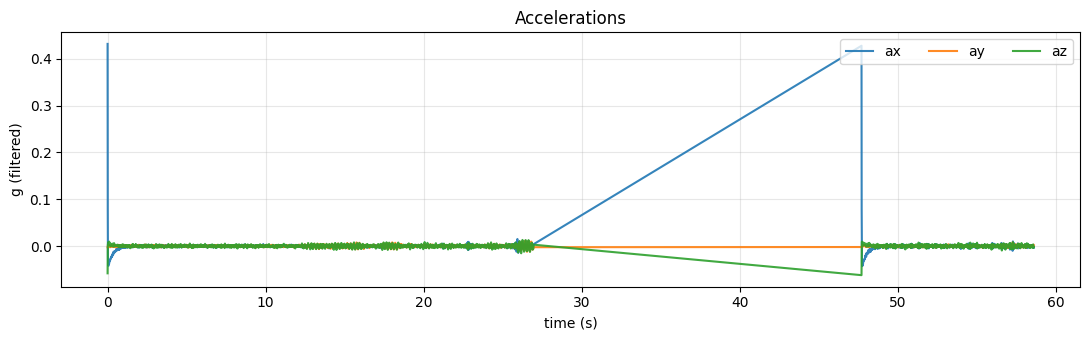

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t, df["ax"], label="ax", alpha=0.9)
ax.plot(t, df["ay"], label="ay", alpha=0.9)
ax.plot(t, df["az"], label="az", alpha=0.9)
ax.set_xlabel("time (s)")
ax.set_ylabel("g (filtered)")
ax.set_title("Accelerations")
ax.legend(loc="upper right", ncol=3)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Magnitude and slope

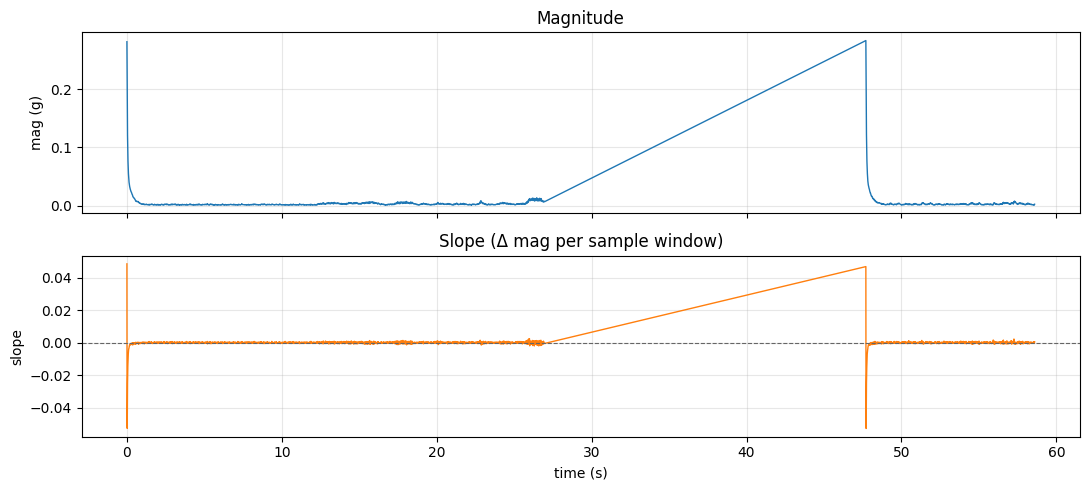

In [4]:
fig, (a0, a1) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
a0.plot(t, df["mag"], color="C0", lw=1.0)
a0.set_ylabel("mag (g)")
a0.set_title("Magnitude")
a0.grid(True, alpha=0.3)

a1.plot(t, df["slope"], color="C1", lw=1.0)
a1.set_xlabel("time (s)")
a1.set_ylabel("slope")
a1.set_title("Slope (Δ mag per sample window)")
a1.axhline(0, color="0.4", ls="--", lw=0.8)
a1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Optional: slope sign changes

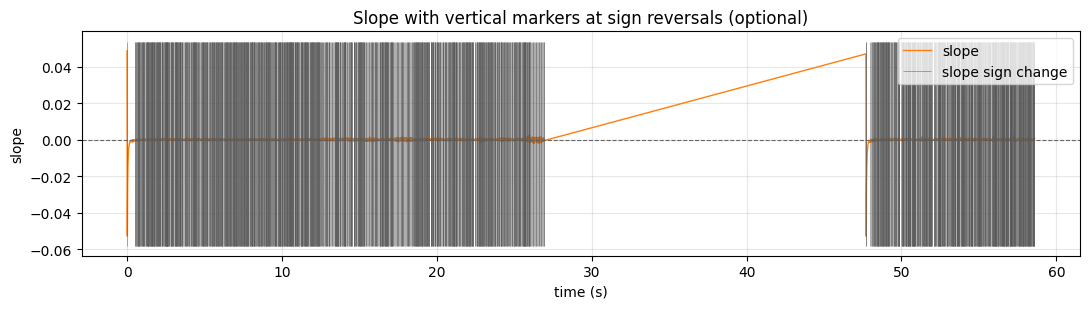

In [5]:
s0 = df["slope"].shift(1)
s1 = df["slope"]
cross = (
    s0 * s1
) < 0  # sign change straddles two samples; ignore exact zeros in product
cross = cross & s0.notna() & s1.notna() & s0.ne(0) & s1.ne(0)
idx = df.index[cross]

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(t, df["slope"], color="C1", lw=1.0, label="slope")
ax.axhline(0, color="0.4", ls="--", lw=0.8)
if len(idx) > 0:
    t_mark = t.loc[idx].values
    y0, y1 = ax.get_ylim()
    ax.vlines(
        t_mark, y0, y1, colors="0.35", lw=0.7, alpha=0.5, label="slope sign change"
    )
ax.set_xlabel("time (s)")
ax.set_ylabel("slope")
ax.set_title("Slope with vertical markers at sign reversals (optional)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Optional: markers for local peaks in magnitude (heuristic for oscillation / step-related bumps)

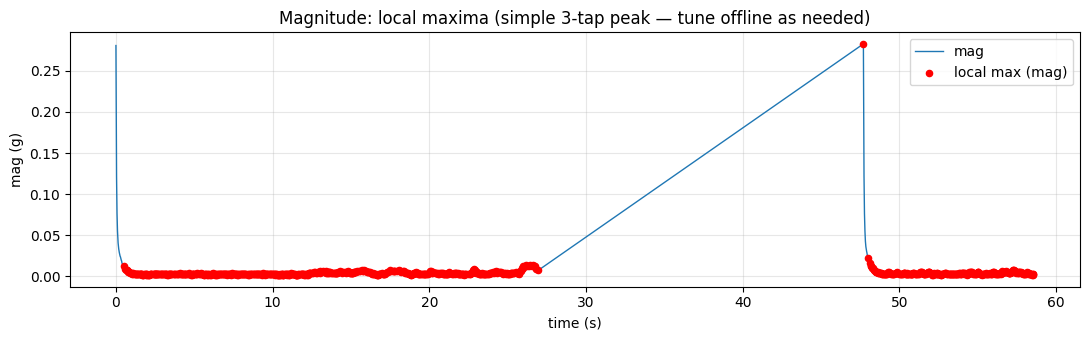

In [6]:
m = df["mag"]
is_peak = (m > m.shift(1)) & (m > m.shift(-1))
is_peak = is_peak.fillna(False)
peak_t = t[is_peak]
peak_m = m[is_peak]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t, m, color="C0", lw=1.0, label="mag")
if not peak_t.empty:
    ax.scatter(peak_t, peak_m, color="red", s=20, zorder=5, label="local max (mag)")
ax.set_xlabel("time (s)")
ax.set_ylabel("mag (g)")
ax.set_title("Magnitude: local maxima (simple 3-tap peak — tune offline as needed)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()